In [50]:
# импортирую все библиотеки, что потенциально могут понадобиться
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use('default')
import plotly
import plotly.express as px
import seaborn as sns

In [51]:
churn_data = pd.read_csv('data/churn.csv')
churn_data = churn_data.drop(['RowNumber'], axis=1)
churn_data.head(1)

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.0,1,1,1,101348.88,1


Столбцы таблицы:

* RowNumber — номер строки таблицы (это лишняя информация, поэтому можете сразу от неё избавиться)
* CustomerId — идентификатор клиента
* Surname — фамилия клиента
* CreditScore — кредитный рейтинг клиента (чем он выше, тем больше клиент брал кредитов и возвращал их)
* Geography — страна клиента (банк международный)
* Gender — пол клиента
* Age — возраст клиента
* Tenure — сколько лет клиент пользуется услугами банка
* Balance — баланс на счетах клиента в банке
* NumOfProducts — количество услуг банка, которые приобрёл клиент
* HasCrCard — есть ли у клиента кредитная карта (1 — да, 0 — нет)
* IsActiveMember — есть ли у клиента статус активного клиента банка (1 — да, 0 — нет)
* EstimatedSalary — предполагаемая заработная плата клиента
* Exited — статус лояльности (1 — ушедший клиент, 0 — лояльный клиент)

Задача: **установить, чем ушедшие клиенты отличаются от лояльных и как между собой связаны различные признаки, определяющие клиентов**

In [52]:
churn_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerId       10000 non-null  int64  
 1   Surname          10000 non-null  str    
 2   CreditScore      10000 non-null  int64  
 3   Geography        10000 non-null  str    
 4   Gender           10000 non-null  str    
 5   Age              10000 non-null  int64  
 6   Tenure           10000 non-null  int64  
 7   Balance          10000 non-null  float64
 8   NumOfProducts    10000 non-null  int64  
 9   HasCrCard        10000 non-null  int64  
 10  IsActiveMember   10000 non-null  int64  
 11  EstimatedSalary  10000 non-null  float64
 12  Exited           10000 non-null  int64  
dtypes: float64(2), int64(8), str(3)
memory usage: 1015.8 KB


* Итого имеем 3 категориальных признака - ['Surname','Geography','Gender']
* Пропусков в таблице нет

***9.1. Каково соотношение ушедших и лояльных клиентов? Покажите это на графике и дайте комментарий по соотношению.***

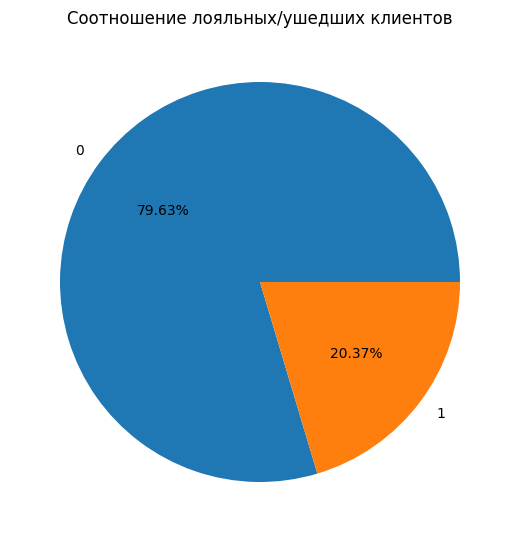

In [53]:
exited_status = churn_data['Exited'].value_counts()

fig = plt.figure(figsize=(5, 5))
axes = fig.add_axes([0, 0, 1, 1])
axes.set_title('Соотношение лояльных/ушедших клиентов', fontsize=12)
axes.pie(
    exited_status,
    labels=exited_status.index,
    autopct='%.2f%%',
    
);

*Обоснование метода*.
Общее количество клиентов - 100%. Делится на 2 категории - лояльных(0) и ушедших(1). Максимально информативно показывает метод ```pie()```

*Вывод*: соотношение лояльных/ушедших клиентов - 79,63/20,37 = 3,9/1

--------

***9.2. Постройте график, показывающий распределение баланса пользователей, у которых на счету больше 2 500 долларов. Опишите распределение и сделайте выводы.***

In [54]:
# отсортируем клиентов по уровню баланса > 2.500$
sorted_balance = churn_data[churn_data['Balance'] > 2500]
display(sorted_balance.head(5))

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
7,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1


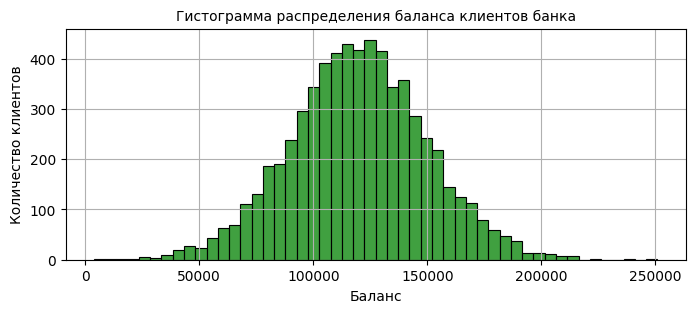

In [55]:
# Строим гистограмму
fig = plt.figure(figsize=(8, 3))
axes = sns.histplot(
    data=sorted_balance,
    x = 'Balance',
    color = 'green',
    bins=50,
    kde=False,
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Обоснование метода*. Распределение по 1 числовому признаку - гистограмма.

*Вывод*: на графике выраженный пик в диапазоне от 110.000 до 140.000. Это говорит о том, что у большинства клиентов баланс лицевого счета находится в этом диапазоне. Как видно, баланс более 200.000$ имеют единицы клиентов, как и баланс менее 30.000$

------------

***9.3. Посмотрите на распределение баланса клиента в разрезе признака оттока. Как различаются суммы на накопительном счёте ушедших и лояльных клиентов? Подумайте и напишите, с чем это может быть связано, что может не устраивать ушедших клиентов в банке.***

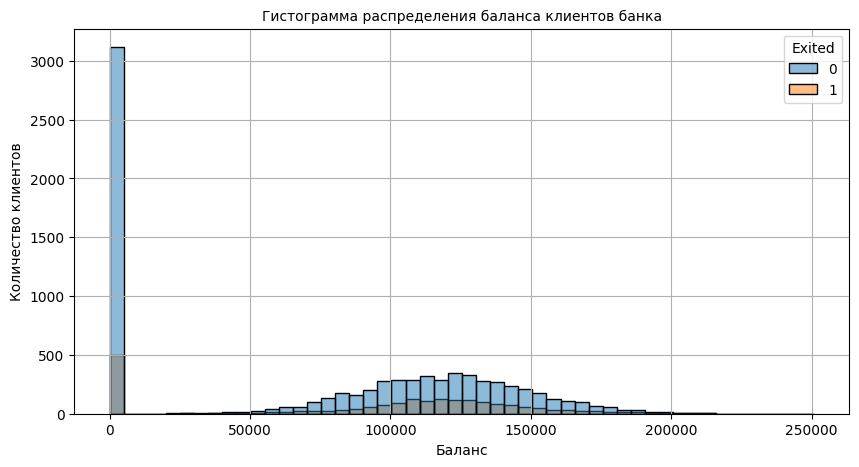

In [ ]:
fig = plt.figure(figsize=(10, 5))
axes =sns.histplot(
    data=churn_data,
    x='Balance',
    bins=50,
    kde=False,
    hue = 'Exited'
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Обоснование выбора метода*. Как и в предыдущем задании, гистограмма удобна для просмотра меняющегося показателя (balance). Атрибутом ```hue``` мы добавили на ту же числовую прямую баланса второй признак - ушедших клиентов.


*Предварительный вывод*. Мы построили график для всех клиентов банка, так как в условиях не было указана фильтрация. Более, чем у 3000 лояльных клиентов на балансе нет денег. Также баланс около 0 у около 500 ушедших клиентов.
Чтобы нагляднее увидеть разницу в балансе клиентов, отфильтруем баланс от 50.000$ до 200.000$

In [70]:
sorted_balance2 = churn_data[(churn_data['Balance'] > 50000) & (churn_data['Balance'] < 200000)]

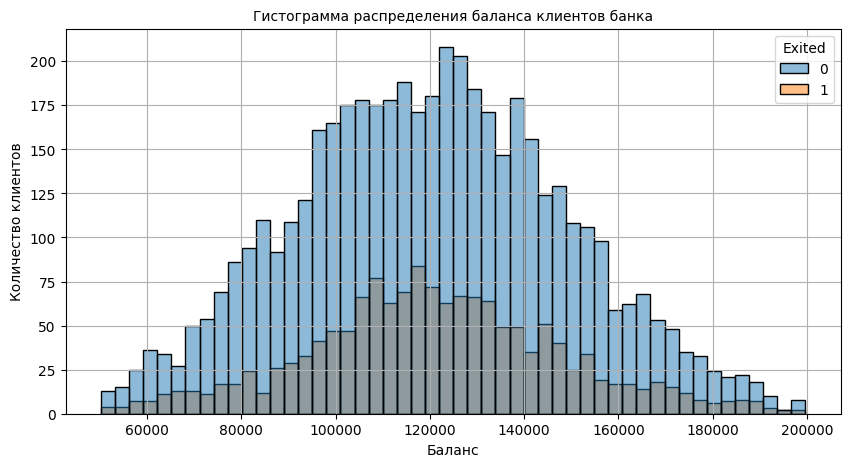

In [71]:
fig = plt.figure(figsize=(10, 5))
axes =sns.histplot(
    data=sorted_balance2,
    x='Balance',
    bins=50,
    kde=False,
    hue = 'Exited'
);
# Оформление
axes.set_title('Гистограмма распределения баланса клиентов банка', fontsize=10);
axes.set_xlabel('Баланс');
axes.set_ylabel('Количество клиентов');
axes.grid()

*Вывод*:
* Как видно из  основного распределения, баланс лояльных клиентов выше баланса ушедших в 2-3 раза.
* Для того, чтобы понять в чем причина разницы балансов, необходимо провести дополнительные исследования ушедших клиентов: их кредитный рейтинг, страну, пол, возраст и другие характеристики и поискать там закономерности.
* Что может не устраивать ушедших клиентов? Отказы по кредитам, в случае плохой кредитной истории, высокие комиссии при обслуживании, низкий сервис по сравнении с конкурентами и многое другое

------------

 ***9.4. Посмотрите на распределение возраста в разрезе признака оттока. В какой группе больше потенциальных выбросов? На какую возрастную категорию клиентов стоит обратить внимание банку?***

c:\Users\1\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_base.py:1608: UserWarning: Vertical orientation ignored with only `x` specified.
  warnings.warn(single_var_warning.format("Vertical", "x"))


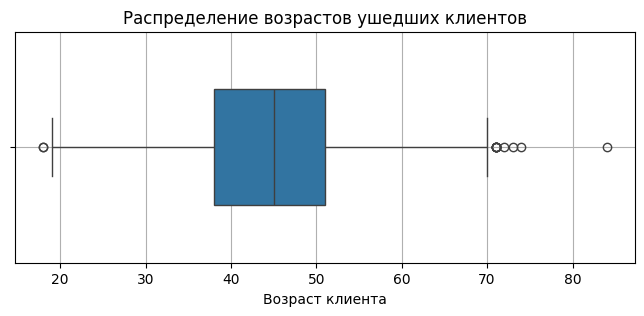

In [ ]:
fig = plt.figure(figsize=(8, 3))
boxplot = sns.boxplot(
    data=churn_data[churn_data['Exited'] == 1],
    x='Age',
    orient='v',
    width=0.5
)
boxplot.set_title('Распределение возрастов ушедших клиентов');
boxplot.set_xlabel('Возраст клиента');
boxplot.grid()

*Обоснование выбора метода*: распределение числового признака в разрезе одного параметра отображается методом ```boxplot()```

*Выводы*: 
* медианное значение ушедших клиентов - 45 лет. 25 квартиль в районе 38 лет, 75 - в районе 52 лет. 
* Наблюдаются единичные выбросы в возрасте до 20 лет, а так же единичный выброс около 85 лет
* Большая часть выбросов сгруппирована от 70 до 75 лет.
* Банку стоит обратить внимание на возрастную группу 38-52 года. Большая часть ушедших клиентов состоит в ней

----------

***9.5. Постройте график, который показывает взаимосвязь кредитного рейтинга клиента и его предполагаемой зарплаты. Добавьте расцветку по признаку оттока клиентов. Какова взаимосвязь между признаками? Если не видите явной взаимосвязи, укажите это.***